In [3]:
# Loading data
import pandas as pd

df_sup = pd.read_csv('supervisado (1).csv')
df_sup.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Target Variable
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


Análisis supervisado
Basado en el contenido de los datos, los tipos de variables y la variable predictora de esta base de datos, considero que Random Forest es la opción más razonable por las siguientes razones:

1. Manejo de variables binarias: La base de datos contiene variables binarias (como Extracurricular Activities), las cuales pueden ser procesadas perfectamente en un modelo de Random Forest mediante la codificación de características (0/1).

2. Relaciones no lineales: Los datos no presentan una relación lineal; por ejemplo, el tiempo de estudio y las calificaciones no mantienen una correlación lineal. Asimismo, existe una cierta correlación entre las horas de estudio y las horas de sueño.

3. Prevención del sobreajuste (Overfitting): El modelo de Random Forest resuelve el problema del sobreajuste mediante la introducción de aleatoriedad tanto en las muestras como en las características, lo que mejora significativamente la capacidad de generalización del modelo.

In [15]:
# import random forest library
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# data preparation: convert literal binary variable to numeric binary variable
df_sup['Extracurricular Activities'] = df_sup['Extracurricular Activities'].map({'Yes': 1, 'No': 0})

# data preparation: define the feature variables and target variable
X = df_sup.drop('Target Variable', axis=1)
y = df_sup['Target Variable']

# split dataset to training, validating and testing dataset(60%, 20%, 20%)
X_train_temp, X_test, y_train_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_temp, y_train_temp, test_size=0.25, random_state=42)

print(f"dataset: trainingset({len(X_train)}), Validatingset{len(X_val)}), testingset({len(X_test)})")

# Hyperparameter tuning
best_mae = float('inf')
best_params = {}

print("tuning process")
# try different n_estimaators and mas_depth to get the lowest mae
for n_est in [50, 100, 150]:
    for depth in [None, 10, 20]:
        # training random forest with different parameters
        model = RandomForestRegressor(n_estimators=n_est, max_depth=depth, random_state=42)
        model.fit(X_train, y_train)
        
        # evaluate the parameters of the model with mae
        val_preds = model.predict(X_val)
        mae = mean_absolute_error(y_val, val_preds)
        
        if mae < best_mae:
            best_mae = mae
            best_params = {'n_estimators': n_est, 'max_depth': depth}

print(f"\n[result] best parameters: {best_params}, best mae: {best_mae:.4f}")

# final evaluation of the model with testing data set
final_rf = RandomForestRegressor(n_estimators=150, max_depth=10, random_state=42)
final_rf.fit(X_train, y_train)
y_test_pred = final_rf.predict(X_test)
final_mae = mean_absolute_error(y_test, y_test_pred)
final_r2_score = r2_score(y_test, y_test_pred)
print(f"final MAE: {final_mae}")
print(f"final R2: {final_r2_score}")

dataset: trainingset(6000), Validatingset2000), testingset(2000)
tuning process

[result] best parameters: {'n_estimators': 150, 'max_depth': 10}, best mae: 1.7654
final MAE: 1.7762204640881119
final R2: 0.9866014576025021


[0.14340679 0.84971698 0.         0.0035661  0.00331012]


C:\Users\ayidi\AppData\Local\Temp\ipykernel_25904\3816687289.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances, y=X.columns, palette='viridis')


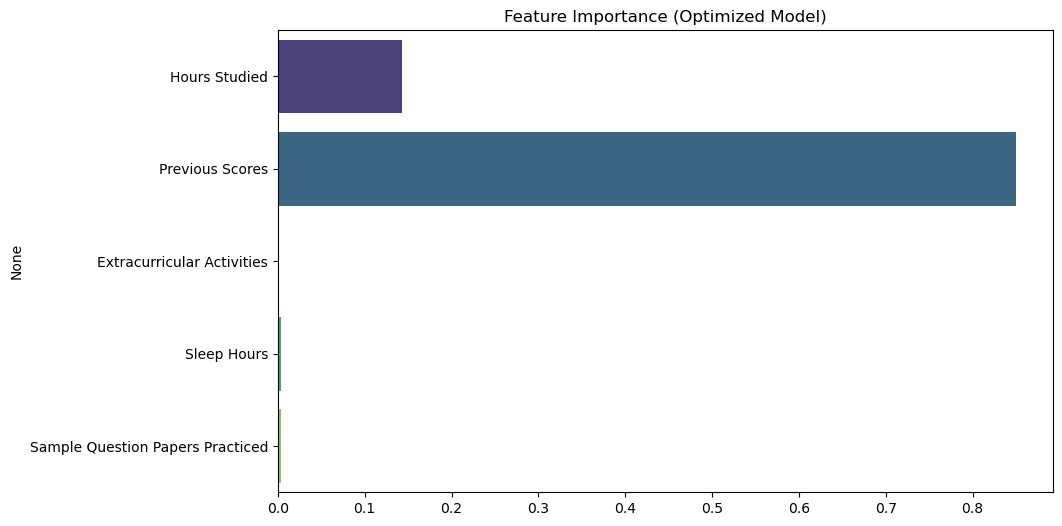

In [16]:
# explain the importance of each variable
importances = final_rf.feature_importances_
print(importances)
plt.figure(figsize=(10, 6))
importances = final_rf.feature_importances_
sns.barplot(x=importances, y=X.columns, palette='viridis')
plt.title('Feature Importance (Optimized Model)')
plt.show()

Interpretación de la Importancia de las Características (Feature Importance)Basándonos en los valores de importancia de las características del modelo Random Forest, podemos realizar la siguiente interpretación:
1. Previous Score (84.97%): Con un peso del 84.97%, este valor indica que aproximadamente el 85% de la decisión del modelo al predecir la calificación final se basa en el historial académico del estudiante. Desde una lógica matemática, esto sugiere una correlación lineal extremadamente fuerte y una dependencia de trayectoria entre las calificaciones previas y los resultados finales.
   
2. Hours Studied (14.34%): Aunque su peso es significativamente menor que el de los resultados previos, sigue siendo una variable indispensable. Representa el "esfuerzo inmediato" del estudiante y es el factor que más influye en el cambio de la predicción más allá de la base académica. El modelo utiliza esta variable para ajustar el "incremento" sobre la puntuación base.

3. Sleep Hours (0.36%) y Sample Papers (0.33%): La suma de ambos pesos es inferior al 1%. Esto significa que, para el modelo de Random Forest, incluso cambios drásticos en estos valores tienen un impacto mínimo en la predicción final. Actúan más como "ruido de fondo" que solo sirve para ajustes finos en casos extremos.

4. Extracurricular Activities (0.0%): Un valor de 0.0 implica que esta variable binaria no se utilizó en absoluto para la división de nodos durante el entrenamiento del modelo. En otras palabras, la participación o no en actividades extracurriculares no altera en absoluto el valor predictivo generado por el modelo.

In [40]:
import pandas as pd

# loading dataset
# original dataset contains: driver_id, mean_distance_day, mean_over_speed_percentage
df_nonsup = pd.read_csv('no_supervisado (1).csv')
df_nonsup.head()

,driver_id,mean_distance_day,mean_over_speed_percentage
0,3423311935,71.24,28
1,3423313212,52.53,25
2,3423313724,64.54,27
3,3423311373,55.69,22
4,3423310999,54.58,25


Análisis nosupervisado
Basándonos en los datos contenidos en la base de datos, realizaremos un análisis de clústeres (segmentación) de los conductores, fundamentado en la distancia promedio diaria recorrida y el porcentaje promedio de exceso de velocidad.

Antes de iniciar el análisis de K-means, es fundamental utilizar el Método del Codo (Elbow Method) para determinar el valor óptimo de K. La lógica de este método consiste en probar diferentes valores de K para obtener una curva que represente la variación de la WCSS (Suma de Cuadrados Dentro del Clúster) en función de K. El objetivo es identificar el punto donde la curva comienza a aplanarse, el cual se define como el punto de codo óptimo.

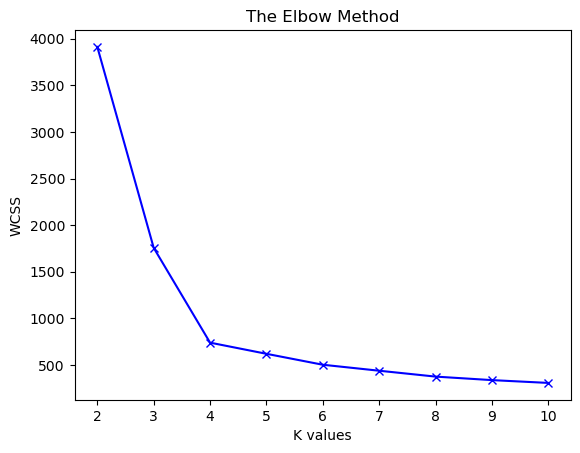

In [43]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# feature selection
X = df_nonsup[['mean_distance_day', 'mean_over_speed_percentage']]

# standardization of the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# calculate the wcss with different K value
wcss = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)  

# visualize the elbow curve
plt.plot(K_range, wcss, 'bx-')
plt.xlabel('K values')
plt.ylabel('WCSS')
plt.title('The Elbow Method')
plt.show()

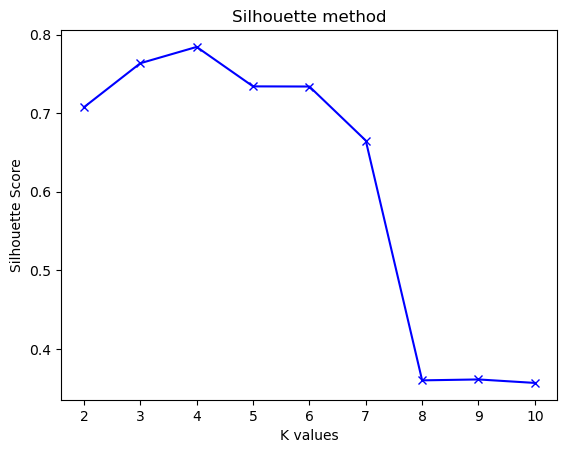

In [53]:
from sklearn.metrics import silhouette_score

# calculate the scores with different K value
scores = []
for k in range(2, 11): 
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeans.fit(X_scaled)
    score = silhouette_score(X_scaled, kmeans.labels_)
    scores.append(score)

# visualize the Silhouette curve
plt.plot(K_range, scores, 'bx-')
plt.xlabel('K values')
plt.ylabel('Silhouette Score')
plt.title('Silhouette method')
plt.show()

Consistencia en la Selección del Valor Óptimo de K
Los resultados obtenidos son sumamente consistentes y estándar según ambos criterios de evaluación:
1. Método del Codo (Elbow Method): En el gráfico de la WCSS, se observa una caída drástica entre K=2 y K=4. El "punto de codo" o punto de inflexión aparece de manera evidente en K=4, lo que indica que añadir más clústeres a partir de este punto no reduce significativamente la varianza interna.
2. Coeficiente de Silueta (Silhouette Score): Al analizar el gráfico de silueta, el valor máximo se alcanza precisamente en K=4. Esto confirma que, con esta partición, las fronteras entre los clústeres son lo más nítidas posible y cada punto de dato presenta la mayor similitud con su propio grupo (alta cohesión) y la mayor diferencia con los demás (alta separación).

Conclusión: Dado que tanto el criterio de inercia como el de estructura coinciden, se determina que 4 es el número óptimo de clústeres para segmentar de manera robusta esta base de datos.

In [54]:
# create the kmeans model with K value equal to 4
opt_k = 4
kmeans = KMeans(n_clusters=opt_k, random_state=42, n_init=10)

# 3. train the model
kmeans.fit(X_scaled)

# 4. Labels and the Centroides de los clústeres
labels = kmeans.labels_          
centroids = kmeans.cluster_centers_  

print(f"labels: {labels}")
print(f"centroides: {centroids}")

labels: [2 2 2 ... 1 1 1]
centroides: [[-0.48678423 -0.40249736]
 [ 1.95263225 -0.0139714 ]
 [-0.47952334  1.57909169]
 [ 1.90400473  4.34582367]]


Hiperparámetros del Modelo K-meansDentro del modelo K-means, los hiperparámetros fundamentales se definen de la siguiente manera:
1. n_clusters (K): Representa el número de clústeres o grupos en los que se dividirán los datos no etiquetados. El valor óptimo de este hiperparámetro debe determinarse mediante el análisis del Método del Codo (Elbow Method) y el Coeficiente de Silueta.
2. random_state: Controla la determinación de la posición inicial de los centroides (inicialización aleatoria). Este valor asegura la reproducibilidad de los resultados, permitiendo que el algoritmo encuentre los mejores centroides tras múltiples iteraciones iniciales.
3. n_init: Representa el número de inicializaciones independientes. Es decir, el algoritmo ejecuta internamente el proceso de K-means n veces de forma aislada y selecciona el resultado con la menor WCSS (el que logre clústeres más compactos y con mejor desempeño). Por lo general, su valor predeterminado es 10. Sin embargo, cuando la distribución de los datos es compleja o el valor de K es muy elevado, se puede aumentar n_init para incrementar la precisión del cálculo.
4. init (K-means++): Cuando el volumen de datos alcanza una escala de miles de millones y cada ejecución requiere demasiado tiempo, se suele utilizar el hiperparámetro init configurado como k-means++. Este método optimiza la selección inicial de los centroides para que estén lo más alejados posible entre sí, permitiendo obtener resultados óptimos con una única ejecución inicial (n_init = 1).

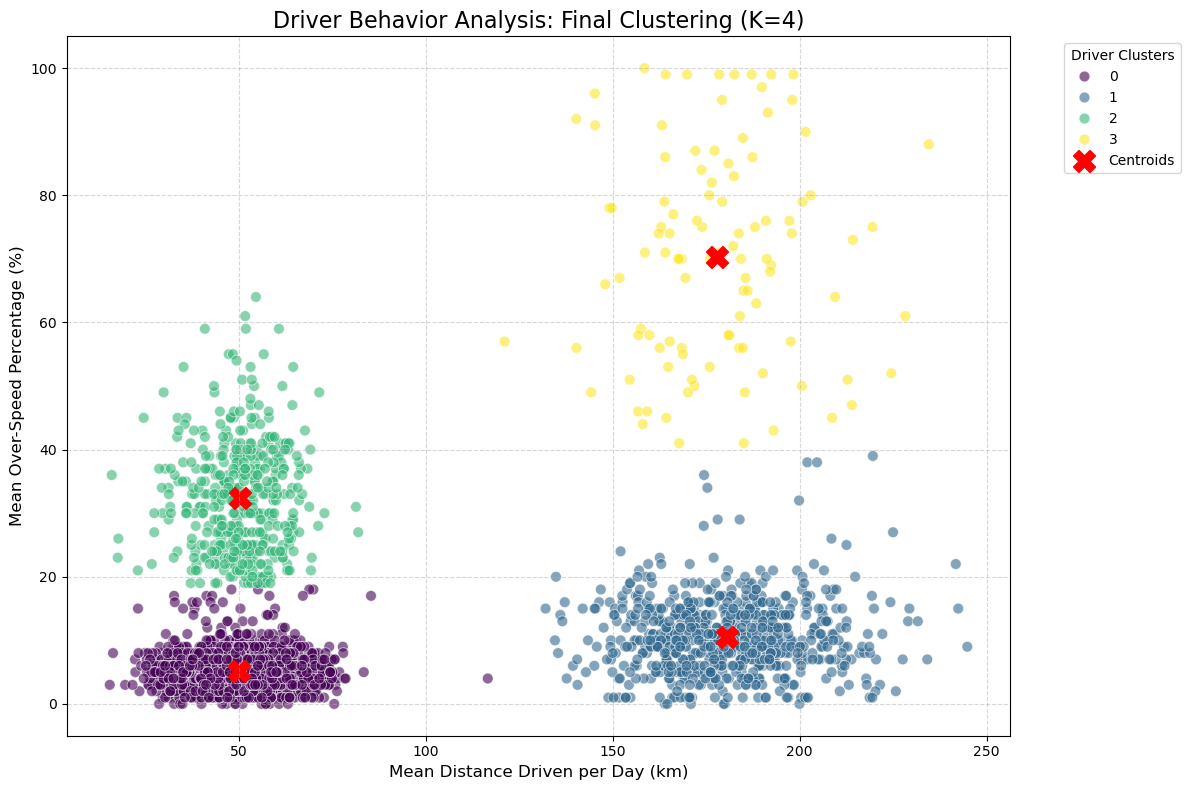

--- Overall characteristics of different clusters ---
         mean_distance_day  mean_over_speed_percentage
Cluster                                               
0                50.016637                    5.204037
1               180.434863                   10.529496
2                50.404824                   32.365340
3               177.835096                   70.288462


In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

# visualize those clusters with centroides
df_nonsup['Cluster'] = kmeans.fit_predict(X_scaled)
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df_nonsup, 
    x='mean_distance_day', 
    y='mean_over_speed_percentage', 
    hue='Cluster', 
    palette='viridis', 
    s=60, 
    alpha=0.6)

centroids_scaled = kmeans.cluster_centers_
centroids = scaler.inverse_transform(centroids_scaled)

plt.scatter(
    centroids[:, 0], 
    centroids[:, 1], 
    c='red', 
    marker='X', 
    s=250, 
    label='Centroids')
plt.title(f'Driver Behavior Analysis: Final Clustering (K={opt_k})', fontsize=16)
plt.xlabel('Mean Distance Driven per Day (km)', fontsize=12)
plt.ylabel('Mean Over-Speed Percentage (%)', fontsize=12)
plt.legend(title='Driver Clusters', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# final feature of different clusters
print("--- Overall characteristics of different clusters ---")
print(df_nonsup.groupby('Cluster')[['mean_distance_day', 'mean_over_speed_percentage']].mean())

Perfilado de Conductores por Clústeres (K=4)Basándonos en los centroides obtenidos, hemos categorizado a los conductores en cuatro perfiles distintivos:
1. Conductor Urbano Prudente (Clúster 0)Características: Distancia diaria corta (approx ≈ 50 km) y exceso de velocidad mínimo (promedio < 6\%).Perfil: Operan principalmente en zonas urbanas fijas. Poseen un estilo de conducción conservador y un alto cumplimiento de las normas de tráfico.
2. Conductor Urbano de Alto Riesgo (Clúster 2)Características: Distancia corta (approx ≈ 50 km), pero con un porcentaje de exceso de velocidad alarmante (promedio > 30% ).Perfil: Aunque no realizan trayectos largos, suelen realizar maniobras bruscas y exceso de velocidad en calles urbanas o vías rápidas. Es el típico conductor "impaciente", con alta probabilidad de causar colisiones en ciudad.
3. Conductor Profesional de Larga Distancia (Clúster 1)Características: Gran distancia diaria (approx ≈ 180 km) y exceso de velocidad en un nivel medio-bajo (approx ≈ 10%).Perfil: Principalmente conductores profesionales (transporte de carga o pasajeros interurbano). A pesar del alto kilometraje, son conscientes de los riesgos y mantienen un estilo de conducción relativamente racional.
4. Conductor de Riesgo Extremo (Clúster 3)Características: "Doble Alto" — Distancia extrema (approx ≈ 178 km) y exceso de velocidad crítico (promedio > 70%).Perfil: Representan la mayor amenaza para la seguridad vial. Conducen a exceso de velocidad durante casi todo el trayecto en autopistas de larga distancia.